In [1]:
import pandas as pd
import numpy as np

# Load dataset
data = pd.read_csv("water_quality_prediction_project_dataset.csv")

# Display first 5 rows
print(data.head())

      ph  Hardness     Solids  Chloramines  Sulfate  Conductivity  \
0  7.417    70.016  39860.096        8.854  139.049       610.050   
1  5.787   154.362   9779.476        8.176  198.266       673.283   
2  5.709   253.079  20749.801       10.186  356.405       596.233   
3  6.903   173.246  15913.176        9.380  265.289       253.672   
4  9.460   116.421  26719.922        5.757  394.423       476.264   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0          28.816           36.903      1.079           0  
1          23.401           78.134      5.982           0  
2          18.757           83.629      6.366           0  
3          29.792          112.148      5.046           0  
4          27.744           66.320      4.494           0  


In [2]:
print("Dataset Shape:", data.shape)

print("\nColumn Names:")
print(data.columns)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nPotability Distribution:")
print(data["Potability"].value_counts())

Dataset Shape: (5000, 10)

Column Names:
Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

Missing Values:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

Potability Distribution:
Potability
0    2643
1    2357
Name: count, dtype: int64


In [3]:
# Input features
X = data.drop("Potability", axis=1)

# Target variable
y = data["Potability"]

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input Features:
      ph  Hardness     Solids  Chloramines  Sulfate  Conductivity  \
0  7.417    70.016  39860.096        8.854  139.049       610.050   
1  5.787   154.362   9779.476        8.176  198.266       673.283   
2  5.709   253.079  20749.801       10.186  356.405       596.233   
3  6.903   173.246  15913.176        9.380  265.289       253.672   
4  9.460   116.421  26719.922        5.757  394.423       476.264   

   Organic_carbon  Trihalomethanes  Turbidity  
0          28.816           36.903      1.079  
1          23.401           78.134      5.982  
2          18.757           83.629      6.366  
3          29.792          112.148      5.046  
4          27.744           66.320      4.494  

Target:
0    0
1    0
2    0
3    0
4    0
Name: Potability, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 9)
Testing data: (1000, 9)


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [8]:
y_pred = model.predict(X_test_scaled)

print("Predicted values:")
print(y_pred[:20])

Predicted values:
[0 1 1 0 1 0 0 0 1 0 0 1 0 0 0 0 1 1 1 0]


In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")

Accuracy : 88.4 %
Precision: 88.01 %
Recall   : 87.26 %
F1 Score : 87.63 %


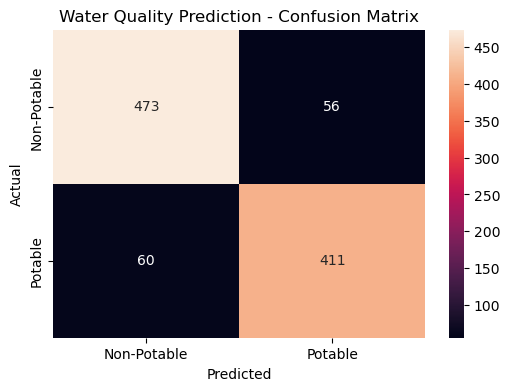

In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Non-Potable", "Potable"],
    yticklabels=["Non-Potable", "Potable"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Water Quality Prediction - Confusion Matrix")

plt.show()

In [11]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-Potable", "Potable"]
))

              precision    recall  f1-score   support

 Non-Potable       0.89      0.89      0.89       529
     Potable       0.88      0.87      0.88       471

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



In [12]:
new_water = pd.DataFrame([{
    "ph": 7.2,
    "Hardness": 170,
    "Solids": 12000,
    "Chloramines": 6.0,
    "Sulfate": 270,
    "Conductivity": 400,
    "Organic_carbon": 12,
    "Trihalomethanes": 60,
    "Turbidity": 3.0
}])

# Scale new input
new_water_scaled = scaler.transform(new_water)

# Prediction
prediction = model.predict(new_water_scaled)

if prediction[0] == 1:
    print("💧 Water Quality: POTABLE")
else:
    print("💧 Water Quality: NON-POTABLE")

💧 Water Quality: POTABLE
